# 초기 기준선(공개본): 치료받지 않는 청년의 대사이상 위험 선별

> 사용자 제공 `my_model_정리.ipynb`의 공개용 복사본입니다. 개인별 원자료 미리보기, 컴퓨터에 고정된 파일 경로, 환경 경고 출력만 공개용으로 정리하고 이 안내를 추가했습니다. **모델 학습과 지표 계산은 재실행하지 않았습니다.** 남겨 둔 집계표·차트는 원본에 저장된 결과이며, 코드나 출력이 달라진 셀의 실행 번호는 비웠습니다.
>
> 원문의 **주의** 상자는 해석상의 한계를 설명합니다. **정리자 확인**으로 표시한 추가 수치와 SPSS 재현 주장은 제공된 정리본의 기록을 보존한 것이며, 이번 공개 준비에서 별도로 재검증한 결과는 아닙니다.
>
> **분석 범위:** 이 초기 기준선은 치료자 제외 후 5,204명에서 입력 결측을 제거한 **4,680명**, 입력 **11개**, 대사이상 소견 4개 중 하나 이상 여부인 **단일 이진 Target**을 사용합니다. 학습/시험은 3,276명/1,404명입니다. 별도 [v28 실험](../v28/REPORT.md)은 **4,068명**, 인코딩된 입력 **114차원**, **4개 위험 지표와 16개 조합 상태**를 다루는 5-fold 설계 비교입니다. 표본·입력·목표·평가 방식이 달라 두 실험의 점수를 직접 비교하면 안 됩니다.

## 한눈에 보기

| 항목 | 내용 |
|---|---|
| 연구 질문 | 피를 뽑지 않고 설문과 줄자로 얻는 정보만으로, 본인이 모르는 대사이상 위험을 미리 가려낼 수 있을까? |
| 자료 | 국민건강영양조사(KNHANES) 2021–2024년 |
| 대상 | 만 19–39세 중 고혈압·당뇨병·이상지질혈증 **치료를 받지 않는** 사람 → 빈 값 제거 후 **4,680명** |
| 정답(Target) | 공복혈당·혈압·중성지방·HDL 콜레스테롤 중 **1개 이상 기준 초과** = 위험군(1) |
| 입력 11개 | 나이, 성별, 소득, 교육, BMI, 허리둘레, 허리/키 비율(WHtR), 흡연, 음주, 운동, 1인 가구 |
| 모델 4개 | 로지스틱 회귀, 랜덤 포레스트, XGBoost, LightGBM |
| 핵심 결과 | **로지스틱 회귀**가 ROC-AUC **0.805**, PR-AUC **0.695**로 가장 높음 |
| 선별 기준 | 위험 확률 0.363 이상이면 '위험' → 민감도 **75.5%**, 특이도 **74.4%** |
| 관련 요인 | 현재 흡연(오즈비 1.50), 허리둘레(1cm당 1.107), 나이(1세당 1.046) |

## 순서
1. 준비 · 2. 원자료 열어보기 · 3. 변수 모으기 · 4. 대상자 고르기 · 5. 정답 만들기 · 6. 입력 만들기와 데이터 나누기
7. **네 가지 모델 쉽게 이해하기** (로지스틱 회귀 · 랜덤 포레스트 · XGBoost · LightGBM · 성능 지표) → 학습과 비교
8. 변수 중요도 · 9. Table 1 · 10. 선별 기준(Youden)과 혼동행렬 · 11. Table 2 오즈비 · 12. Forest plot
13. 성별·연령대 하위집단 · 14. 1인 가구 분석 · 15. 종합 정리

## 1. 준비: 도구 불러오기

| 도구 | 하는 일 |
|---|---|
| `pandas` | 엑셀 같은 표(데이터프레임)를 다룸 |
| `numpy` | 숫자 계산 |
| `pyreadstat` | SAS·SPSS 형식의 통계 파일을 읽음 (KNHANES 원자료가 이 형식) |
| `warnings` | 결과와 상관없는 경고 메시지를 숨김 |

In [2]:
import os,warnings,pyreadstat
import pandas as pd 
import numpy as np 
#pyreadstat(python + read + statistical data)으로 sas나 spss 파일 읽어오는 도구
warnings.filterwarnings('ignore')

# 사소한 버전 불일치 경고같은거 무시

## 2. 2024년 원자료 열어보기

**국민건강영양조사(KNHANES)** 는 질병관리청이 해마다 무작위로 뽑은 가구를 찾아가 건강 설문, 신체 계측(키·몸무게·허리둘레·혈압), 혈액검사, 영양조사를 하는 국가 통계입니다. 파일에서 한 행은 한 사람, 한 열은 한 조사 항목입니다.

아래 셀은 2024년 파일 구조를 확인하는 단계입니다. 결과는 **6,997명 × 813개 항목**입니다.

> 원자료는 공개 저장소에 포함하지 않습니다. 별도로 확보한 `hn21_all.sas7bdat`부터 `hn24_all.sas7bdat`까지 네 파일을 저장소의 `data/raw/`에 두어야 합니다. 아래 코드는 작업 디렉터리가 저장소 루트 또는 `notebooks/`인 경우 이 상대 위치를 사용합니다. 개인별 미리보기 대신 크기와 열 이름만 출력합니다.

In [ ]:
from pathlib import Path

run_dir = Path.cwd()
project_root = run_dir.parent if run_dir.name == 'notebooks' else run_dir
data_dir = project_root / 'data' / 'raw'
file_path = str(data_dir / 'hn24_all.sas7bdat')

df_24, meta = pyreadstat.read_sas7bdat(file_path)

print(f"2024년 데이터 크기: {df_24.shape}")
print("2024년 열 이름:", list(df_24.columns))

2024년 데이터 크기: (6997, 813)


## 3. 4개년 자료에서 필요한 변수만 모으기

2021–2024년 파일을 차례로 열어, 아래 25개 열 중 파일에 있는 것만 골라 하나의 표(`df_all`)로 합칩니다.

| 변수 | 뜻 (KNHANES 이용지침서 기준) | 쓰임 |
|---|---|---|
| `ID`, `year` | 개인 아이디, 조사연도 | 식별 |
| `age` | 만 나이 | 입력 |
| `sex` | 성별 (1 남자, 2 여자) | 입력 |
| `incm` | 개인 소득 4분위 (1 하, 2 중하, 3 중상, 4 상) | 입력 |
| `edu` | 교육수준 (1 초졸 이하, 2 중졸, 3 고졸, 4 대졸 이상) | 입력 |
| `cfam` | 가구원 수 (1 = 혼자 삶) | 1인 가구 변수 만들 때 |
| `DI1_dg` / `DI1_pt` | 고혈압 의사진단 여부 / 치료 여부 (1 = 있음) | 대상자 제외 (`_pt`) |
| `DE1_dg` / `DE1_pt` | 당뇨병 의사진단 / 치료 | 대상자 제외 (`_pt`) |
| `DI2_dg` / `DI2_pt` | 이상지질혈증 의사진단 / 치료 | 대상자 제외 (`_pt`) |
| `HE_glu` | 공복혈당 (mg/dL) | 정답 |
| `HE_TG` | 중성지방 (mg/dL) | 정답 |
| `HE_HDL_st2` | HDL 콜레스테롤 (mg/dL) | 정답 |
| `HE_sbp` / `HE_dbp` | 수축기 / 이완기 혈압 (mmHg) | 정답 |
| `HE_ht`, `HE_wt` | 키, 몸무게 | WHtR 계산, Table 1 |
| `HE_BMI` | 체질량지수 = 몸무게(kg) ÷ 키(m)² | 입력 |
| `HE_wc` | 허리둘레 (cm) | 입력 |
| `sm_presnt` | 현재 흡연 (1 = 평생 담배 5갑 이상 피웠고 지금도 피움) | 입력 |
| `dr_month` | 월간 음주 (1 = 최근 1년간 월 1회 이상 음주) | 입력 |
| `pa_aerobic` | 유산소 신체활동 실천 (1 = 일주일에 중강도 2시간 30분 이상 또는 고강도 1시간 15분 이상 등) | 입력 |

In [ ]:
selected_cols = [
    'ID', 'year', 'age', 'sex', 'incm', 'edu',
    'cfam',
    'DI1_dg', 'DI1_pt', 'DE1_dg', 'DE1_pt', 'DI2_dg', 'DI2_pt',
    'HE_glu', 'HE_TG', 'HE_HDL_st2', 'HE_sbp', 'HE_dbp',
    'HE_ht', 'HE_wt', 'HE_BMI', 'HE_wc',
    'sm_presnt', 'dr_month', 'pa_aerobic'
]

df_list = []
years = ['21', '22', '23', '24']

for y in years:
    fpath = str(data_dir / f'hn{y}_all.sas7bdat')
    if os.path.exists(fpath):
        print(f'20{y}년 데이터 가져오는 중')
        temp_df, _ = pyreadstat.read_sas7bdat(fpath) 
        # 위에서는 df_24랑 meta 두개의 변수로 받았었다 meta에는 중성지방이나 흡연등 
        # 어떻게 표시해두었는지에 대한 설명을 담고있었다
        # 지금은 필요한 컬럼들만 뽑는 작업이기에 meta데이터는 필요가 없어 _로 표시하였다
        valid_cols=[c for c in selected_cols if c in temp_df.columns]
        df_list.append(temp_df[valid_cols])

df_all=pd.concat(df_list,axis=0,ignore_index=True)
print(f"4개년 결합 데이터 크기: {df_all.shape}")
print("선택 변수:", list(df_all.columns))

2021년 데이터 가져오는 중
2022년 데이터 가져오는 중
2023년 데이터 가져오는 중
2024년 데이터 가져오는 중


## 4. 연구 대상자 고르기

1. **만 19–39세만 남김** → 5,341명
2. **고혈압·당뇨병·이상지질혈증 치료 중인 사람 제외** (`_pt == 1`) → 5,204명 (137명 제외)

치료 중인 사람을 빼는 이유는 두 가지입니다. 약 때문에 혈압·혈당이 낮아져 겉보기에는 정상으로 나올 수 있고, 이미 병을 알고 있는 사람에게는 '선별'이 필요 없습니다.

코드에서 `~`는 조건을 뒤집는 기호(NOT)입니다. `df_young[~med_mask]`는 "치료 중이 **아닌** 사람만"이라는 뜻입니다.

In [5]:
df_young=df_all[(df_all['age']>=19)&(df_all['age']<=39)].copy()
print(f'19~39세 청년층 인원: {len(df_young):,}명')
# len뒤에 ,를 붙이면 5341이 아닌 5,341같이 천 단위로 콤마찍어줌

med_mask = (df_young['DI1_pt'] == 1) | (df_young['DE1_pt'] == 1) | (df_young['DI2_pt'] == 1)
# pt는 약물 복용 및 치료자

df_study = df_young[~med_mask].copy()
# ~는 제외하고라는 의미
print(f"약 복용자 제외 후 최종 연구 대상자: {len(df_study):,}명")

19~39세 청년층 인원: 5,341명
약 복용자 제외 후 최종 연구 대상자: 5,204명


> **주의: '미인지'라는 이름과 실제 제외 기준의 차이**
> 코드는 "현재 **치료** 중"(`_pt == 1`)인 사람만 뺍니다. 의사에게 **진단**은 받았지만 치료는 받지 않는 사람(`_dg == 1`)은 그대로 남습니다.
> **정리자 확인**: 5,204명 중 **96명**이 이런 경우입니다.
> 엄밀히 '미인지(모르는)'라고 부르려면 진단받은 사람도 빼거나, 용어를 '치료받지 않는 청년'으로 바꾸는 편이 정확합니다.

## 5. 정답(Target) 만들기

아래 네 가지 중 **하나라도** 해당하면 위험군(1), 아니면 정상(0)입니다.

| 항목 | 위험 기준 | 변수 |
|---|---|---|
| 공복혈당 | 100 mg/dL 이상 | `HE_glu` |
| 혈압 | 수축기 130 이상 **또는** 이완기 85 mmHg 이상 | `HE_sbp`, `HE_dbp` |
| 중성지방 | 150 mg/dL 이상 | `HE_TG` |
| HDL('좋은') 콜레스테롤 | 남자 40 미만, 여자 50 미만 | `HE_HDL_st2` |

- 대사증후군 진단 기준(NCEP-ATP III 개정)의 5개 항목에서 **허리둘레를 뺀 4개**입니다. 허리둘레는 입력으로 쓰기 때문에 정답에 넣으면 입력이 정답의 일부를 그대로 알려 주게 됩니다(데이터 누수).
- 대사증후군은 5개 중 **3개 이상**일 때 진단합니다. 여기서의 위험군은 **1개 이상**이므로 훨씬 넓은 개념입니다. "대사증후군 예측"이 아니라 **"대사이상 소견 1개 이상 예측"** 입니다.
- HDL 기준이 남녀가 다른 것은 여성이 원래 HDL이 더 높기 때문입니다.

In [6]:
cond_glu=(df_study['HE_glu']>=100)
# 공복혈당은 100미만이 정상
cond_bp = (df_study['HE_sbp'] >= 130) | (df_study['HE_dbp'] >= 85)
# 혈압
cond_tg = (df_study['HE_TG'] >= 150)
# 중성지방 쉽게 말하면 혈액 속 나쁜 기름
cond_hdl = ((df_study['sex'] == 1) & (df_study['HE_HDL_st2'] < 40)) | ((df_study['sex'] == 2) & (df_study['HE_HDL_st2'] < 50))
# 좋은 콜레스테롤 남자는 40미만이면 위험 여자는 50미만이면 위험, 호로몬 차이 때문에 기준치를 다르게 설정
is_abnormal= cond_glu | cond_bp | cond_tg | cond_hdl
df_study['Target']= np.where(is_abnormal,1,0)

print(df_study['Target'].value_counts())

print((df_study['Target'].value_counts(normalize=True) * 100).round(1))


Target
0    3321
1    1883
Name: count, dtype: int64
Target
0    63.8
1    36.2
Name: proportion, dtype: float64


**결과**: 5,204명 중 위험군 **1,883명(36.2%)**, 정상 3,321명(63.8%). 청년 3명 중 1명 이상이 기준을 하나 이상 넘습니다.

> **주의: 검사값이 비어 있으면 '정상'으로 분류됨**
> pandas에서 빈 값(NaN)을 `>= 100` 같은 조건과 비교하면 항상 False가 나옵니다. 그래서 채혈을 하지 않은 사람도 다른 조건에 걸리지 않으면 0(정상)이 됩니다.
> **정리자 확인**: 최종 분석 대상 4,680명 중 **122명**은 검사값이 하나 이상 비어 있고, 그중 **99명**이 정상(0)으로 분류됐습니다. 4명은 검사값 5개가 모두 비어 있어 무조건 0이 됐습니다.
> 이 122명을 빼고 같은 코드로 다시 돌리면 로지스틱 회귀 ROC-AUC 0.793, PR-AUC 0.703이 나옵니다. 결론은 비슷하지만 숫자는 달라집니다.

> **주의: 공복 시간**
> `HE_glu`는 '공복혈당' 항목이지만, 공복 8시간 미만인 사람의 값도 들어 있습니다. 질병관리청 공식 지표는 공복 8시간 이상(`HE_fst >= 8`)인 값만 씁니다.
> **정리자 확인**: 분석 대상 중 **84명**이 여기에 해당합니다.

## 6. 입력 변수 만들기 · 학습/시험 데이터 나누기

**새로 만드는 변수 2개**
- `WHtR` (허리둘레 ÷ 키): 키에 비해 배가 얼마나 나왔는지 보여 줍니다. 흔히 0.5를 넘으면 복부비만 위험 신호로 봅니다. BMI는 근육과 지방을 구분하지 못하므로 이를 보완하려고 추가했습니다.
- `living_alone`: 가구원 수(`cfam`)가 1이면 1인 가구(1). '자취'를 대신하는 지표일 뿐, 실제 자취 여부를 물은 설문은 아닙니다.

**입력 11개**: 모두 휴대폰 앱에서 사용자가 직접 입력하거나 줄자·체중계로 잴 수 있는 정보입니다. 피검사 값은 하나도 쓰지 않습니다.

| 분류 | 변수 |
|---|---|
| 인구·사회 | 나이, 성별, 소득, 교육, 1인 가구 |
| 체형 | BMI, 허리둘레, WHtR |
| 생활습관 | 현재 흡연, 월간 음주, 유산소 운동 |

**빈 값 제거**: 입력 11개(+정답)에 빈 값이 있는 사람을 빼서 **4,680명**이 남습니다.

**학습/시험 나누기** (`train_test_split`)
- **학습 데이터 70% (3,276명)**: 모델이 규칙을 배우는 교과서
- **시험 데이터 30% (1,404명)**: 모델이 학습 때 한 번도 보지 않은 모의고사. 성능은 모두 여기서 잽니다.
- `stratify=y`: 두 데이터의 위험군 비율을 똑같이(약 37%) 맞춥니다.
- `random_state=42`: 실행할 때마다 똑같이 나뉘도록 고정합니다.

In [7]:
from sklearn.model_selection import train_test_split

df_study['WHtR']=df_study['HE_wc']/df_study['HE_ht']
# 허리둘레/키
# bmi는 근육이 많아도 높게 잡혀서 무의미함

df_study['living_alone']=(df_study['cfam']==1).astype(int)

features = [
    'age', 'sex', 'incm', 'edu',
    'HE_BMI', 'HE_wc', 'WHtR',
    'sm_presnt', 'dr_month', 'pa_aerobic',
    'living_alone'
]
# 추후 헬스케어 앱에 적용가능할것인가에 대해서 입증하기 위해 간단한 정보로 실험

data_clean = df_study.dropna(subset=features + ['Target']).copy()
#subset+target을 통하여 다른 열을 검사하지 않고 target열에서만 검사하여 메모리 절약

X = data_clean[features]
y = data_clean['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
# stratify를 사용하여 훈련셋이랑 테스트셋 나눌때 위험군 비율에 맞게 분할해주어서 쏠림 방지
print(f'\n훈련 데이터 크기(X_train):{X_train.shape}')
print(f'시험 데이터 크기(X_test):{X_test.shape}')


훈련 데이터 크기(X_train):(3276, 11)
시험 데이터 크기(X_test):(1404, 11)


> **주의: 원본 주석 두 곳 바로잡기**
> 1. "BMI는 근육이 많아도 높게 잡혀서 무의미함" → BMI도 입력에 그대로 들어갑니다. 정확한 표현은 "BMI만으로는 근육과 지방을 구분하지 못해 WHtR를 추가"입니다.
> 2. `dropna` 주석 "target 열에서만 검사하여 메모리 절약" → 실제로는 **입력 11개 + Target** 열을 검사합니다. 목적은 메모리 절약이 아니라, 분석에 쓰지 않는 열의 빈 값 때문에 사람이 지워지지 않게 하는 것입니다. (Target은 `np.where`로 만들어서 빈 값이 없습니다. 5장 주의 참고)

## 7. 네 가지 모델 쉽게 이해하기

### 공통: 모델이 하는 일
네 모델 모두 **입력 11개를 받아 '위험군일 확률'(0~1)을 내놓는 기계**입니다.
- **학습**: 3,276명의 입력과 정답을 보고, 입력으로 정답을 맞히는 규칙을 찾습니다.
- **평가**: 처음 보는 1,404명에게 확률을 매기고 실제 정답과 비교합니다.

네 모델의 차이는 **규칙을 만드는 방식**입니다. 로지스틱 회귀는 '점수표' 하나를, 나머지 셋은 '질문 나무' 여러 그루를 만듭니다.

---

### 7-1. 로지스틱 회귀: "가중치 점수표"

건강검진 문진표에 항목별 점수를 매겨 합산하는 방식과 비슷합니다.

**① 점수 계산**: 항목마다 가중치(계수, β)를 곱해 더합니다.

$$z = \beta_0 + \beta_1 \times \text{나이} + \beta_2 \times \text{허리둘레} + \dots + \beta_{11} \times \text{1인 가구}$$

β가 양수인 항목은 위험을 올리고, 음수인 항목은 위험을 내립니다.

**② 확률로 바꾸기**: 점수 z는 −∞에서 +∞까지 나올 수 있으므로, S자 모양 곡선(시그모이드)에 넣어 0~1 사이 확률로 바꿉니다.

$$p = \frac{1}{1 + e^{-z}}$$

z가 큰 양수면 p는 1에 가깝고, 0이면 0.5, 큰 음수면 0에 가깝습니다.

**③ 학습**: 3,276명 각각에서 "예측 확률이 실제 정답과 얼마나 어긋났는지(로그 손실)"를 합하고, 이 합이 가장 작아지는 β를 찾습니다.

**오즈와 오즈비** (11장 표를 읽는 열쇠)
- **오즈** = 확률 ÷ (1 − 확률). 확률 0.5는 오즈 1, 확률 0.2는 오즈 0.25입니다.
- **오즈비** = $e^{\beta}$. 다른 항목이 같을 때 그 항목이 1 늘면 오즈가 몇 배가 되는지를 뜻합니다.
- 예: 허리둘레 오즈비 1.107 → 1cm 늘 때마다 위험군일 오즈가 약 10.7% 커지고, 10cm면 약 2.8배(1.107¹⁰)가 됩니다.

**이 노트북의 설정**: `LogisticRegression(max_iter=1000)`
- 기본으로 **L2 규제**(C=1.0)가 들어 있습니다. 계수가 지나치게 커지지 않게 살짝 눌러서 훈련 데이터를 외우는 것(과적합)을 막습니다.
- `max_iter=1000`은 최적의 β를 찾는 반복 계산의 최대 횟수입니다.

**장점**: 결과를 오즈비로 설명할 수 있고, 데이터가 많지 않아도 안정적입니다. 의학 연구에서 표준 기준 모델입니다.
**한계**: 각 항목의 효과가 **서로 더해진다**고 가정합니다. "흡연하면서 허리둘레도 크면 훨씬 더 위험" 같은 조합 효과(상호작용)나 휘어진 관계는 사람이 직접 항목을 만들어 넣어야 합니다.

---

### 7-2. 랜덤 포레스트: "스무고개 나무 100그루의 평균"

**결정나무 한 그루** = 스무고개입니다. (아래 기준값은 설명용 예시)
```
허리둘레 ≥ 85cm?
 ├─ 예 → 나이 ≥ 32세? ─ 예 → [이 칸에 모인 훈련 데이터 사람 중 위험군 70%] → 확률 0.70
 │                   └ 아니오 → ...
 └─ 아니오 → 흡연? ...
```
- 질문(어떤 변수, 어떤 기준값)은 위험군과 정상을 가장 잘 갈라놓는 것으로 자동 선택됩니다.
- 끝 칸(잎)에 도착하면, 그 칸에 모인 훈련 데이터 사람들의 위험군 비율이 예측 확률입니다.

**문제**: 나무 한 그루는 질문을 계속 늘려 훈련 데이터를 통째로 외워 버리기 쉽습니다(과적합).

**해결: 서로 다른 나무 100그루**(`n_estimators=100`)
1. 각 나무는 훈련 데이터 3,276명 중에서 **중복을 허용해 무작위로 뽑은** 3,276명으로 학습합니다(부트스트랩). 그래서 나무마다 보는 사람이 조금씩 다릅니다.
2. 가지를 나눌 때마다 11개 변수 중 **무작위 3개만** 후보로 씁니다. 그래서 나무마다 질문이 달라집니다.
3. 최종 확률 = 100그루 확률의 **평균**. 한 그루의 실수를 다른 나무들이 상쇄합니다.

**이 노트북의 설정**: 기본값이라 나무 깊이에 제한이 없어, 각 나무가 끝까지 자랍니다.
**장점**: 휘어진 관계와 조합 효과를 알아서 잡고, 설정을 거의 안 건드려도 무난합니다.
**한계**: 규칙이 수천 개라 사람이 해석하기 어렵습니다. 관계가 단순하고 데이터가 크지 않으면 이점이 작습니다.

---

### 7-3. XGBoost: "오답노트로 공부하는 나무들"

랜덤 포레스트는 나무를 **각자 따로** 만들어 평균하지만, **부스팅**은 나무를 **한 그루씩 차례로** 만듭니다.
1. 1번 나무가 예측합니다.
2. 사람마다 얼마나 틀렸는지 계산합니다.
3. 2번 나무는 **1번이 틀린 부분을 고치도록** 학습합니다.
4. 3번 나무는 1+2번이 아직 틀린 부분을 고칩니다. 이렇게 100그루까지 반복합니다.
5. 최종 예측 = 모든 나무 예측의 **합**(→ 시그모이드로 확률 변환).

오답노트를 보며 약한 부분만 골라 공부하는 학생과 같습니다. '그래디언트'는 "틀린 정도"를 로그 손실의 기울기로 계산한다는 뜻으로, 손실을 가장 빨리 줄이는 방향으로 다음 나무를 만듭니다.

**과적합을 막는 장치**: 각 나무의 기여를 **학습률**(기본 0.3)만큼 줄여서 더하고, 나무 깊이를 최대 6으로 제한하며, 규제 항이 들어 있습니다.

**이 노트북의 설정**: `XGBClassifier(eval_metric='logloss')`. `eval_metric`은 학습 중 기록할 평가 기준만 정하는 옵션이고, 검증 데이터를 따로 주지 않았으므로 결과에는 영향이 없습니다. 나무 100그루 등 나머지는 기본값입니다.
**장점**: 표 형태 데이터에서 가장 강력한 방법 중 하나입니다.
**한계**: 학습률·깊이·나무 수에 민감해서, 기본값 그대로 쓰면 작은 데이터에서 과적합하기 쉽습니다.

---

### 7-4. LightGBM: "더 빠른 부스팅"

원리는 XGBoost와 같은 그래디언트 부스팅이고, 속도를 높이는 방식 두 가지가 다릅니다.
1. **히스토그램**: 허리둘레 같은 연속값을 최대 255개 구간으로 묶어, 기준값 후보를 빠르게 계산합니다.
2. **잎 우선 성장**: 나무를 층마다 고르게 키우지 않고, **오차를 가장 많이 줄이는 잎 하나를 계속 쪼갭니다**(나무당 잎 최대 31개).

**이 노트북의 설정**: 기본값(나무 100그루, 학습률 0.1). `verbose=-1`은 진행 메시지를 끕니다.
**장점**: 수십만~수백만 행 데이터에서 매우 빠르고 메모리를 적게 씁니다.
**한계**: 잎 우선 성장은 작은 데이터에서 과적합하기 쉽습니다.

> **주의**: 원본 주석 "LightGBM이 현재 데이터 분석 시 가장 효율적"은 큰 데이터 기준의 이야기입니다. 4,680명 규모에서는 네 모델 모두 몇 초 안에 끝나 속도 차이가 의미 없고, 이번 결과에서 가장 좋은 모델도 아니었습니다.

---

### 7-5. 성능 지표 읽는 법

**ROC-AUC**
- 뜻: 위험군 1명과 정상 1명을 무작위로 골랐을 때, 모델이 **위험군 쪽에 더 높은 확률을 줄 확률**입니다.
- 0.5 = 동전 던지기, 1.0 = 완벽. 0.805면 약 80%의 경우 순서를 제대로 매깁니다.
- ROC 곡선: '몇 % 이상이면 위험 판정'이라는 기준을 0부터 1까지 바꿔 가며 (가로: 1 − 특이도, 세로: 민감도) 점을 이은 선입니다. 왼쪽 위로 붙을수록 좋고, 대각선은 무작위 추측입니다.

**PR-AUC** (코드에서는 `average_precision_score`, 평균 정밀도)
- 위험군을 **찾아내는 능력**에 집중한 지표입니다.
  - **정밀도**: '위험'이라고 판정한 사람 중 진짜 위험군의 비율
  - **재현율(= 민감도)**: 진짜 위험군 중 찾아낸 비율
- 아무렇게나 찍었을 때의 기준선은 0.5가 아니라 **위험군 비율**입니다(시험 데이터 519/1,404 = 0.37). 0.695는 기준선의 약 1.9배입니다.

> **주의**: 원본 주석 "PR-AUC는 오직 환자를 환자라고 맞춘 확률만 보여줌"은 방향은 맞지만 부정확합니다. PR-AUC는 정밀도와 재현율을 함께 봅니다. 또 두 지표의 기준선이 다르므로(0.5 vs 0.37) 두 숫자를 같은 잣대로 비교하면 안 됩니다.

**`predict_proba(X_test)[:, 1]`**: 모델이 사람마다 [정상일 확률, 위험군일 확률]을 내놓는데, 그중 두 번째(위험군 확률)만 꺼냅니다. AUC는 이 확률의 **순서**로 계산합니다.

---

### 7-6. 학습하고 비교하기 (실행)
네 모델을 **같은 학습 데이터**로 학습하고 **같은 시험 데이터**로 평가해, ROC 곡선 그림과 성능 표를 만듭니다.

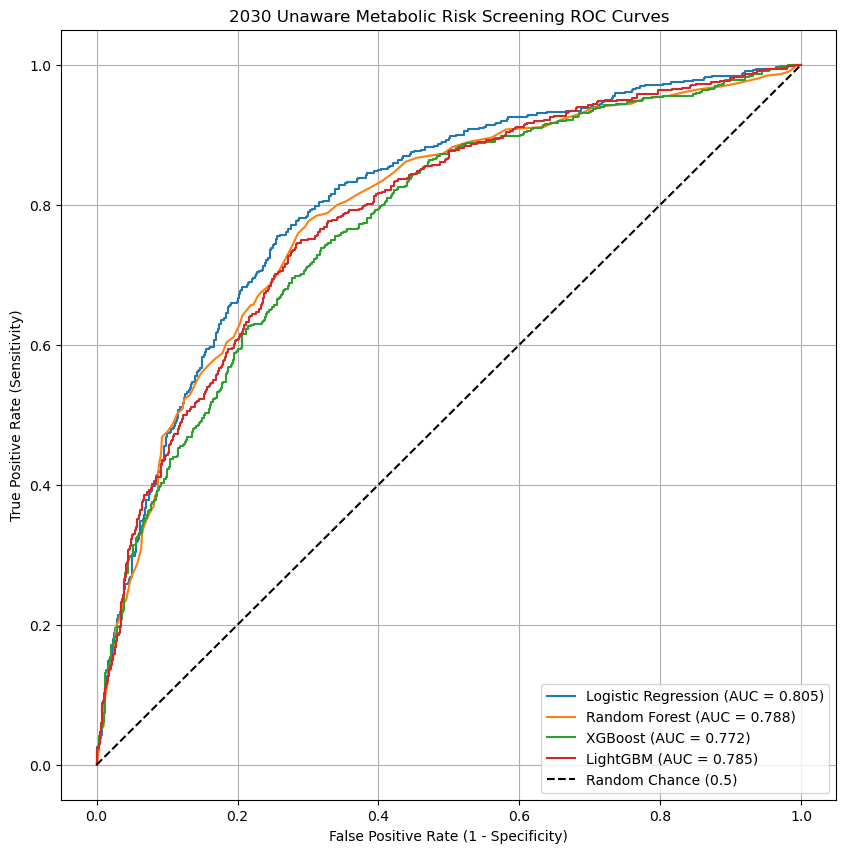

=== 모델별 최종 성능 비교표 ===
              Model  ROC-AUC   PR-AUC
Logistic Regression 0.804777 0.695022
      Random Forest 0.788339 0.673305
           LightGBM 0.785047 0.679596
            XGBoost 0.772004 0.664274


In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score

os.environ['LOKY_MAX_CPU_COUNT']=str(os.cpu_count() or 4)

# 비교 모델 4개
# 로지스틱은 의학 통계의 기준선
# 랜덤 포레스트 트리구조
# XGBoost 오차를 수정하는 그래디언트 모델
# LightGBM 분석 속도가 매우 빠름 현재 데이터분석시 가장 효율적
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

results=[]
plt.figure(figsize=(10,10))

for name,model in models.items():
    model.fit(X_train,y_train)

    y_pred_proba=model.predict_proba(X_test)[:,1]
    # predict_proba()[:,1]은 roc와 auc면적을 매끄럽게 그릴 수 있도록 확률값을 뽑아냄

    auc= roc_auc_score(y_test, y_pred_proba)
    pr_auc=average_precision_score(y_test,y_pred_proba)
    results.append({'Model': name, 'ROC-AUC': auc, 'PR-AUC': pr_auc})
    # ROC-AUC는 정상인을 정상인이라고 맞춘 확률도 포함
    # PR-AUC는 오직 환자를 환자라고 맞춘 확률만 보여줌

    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")


plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (0.5)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('2030 Unaware Metabolic Risk Screening ROC Curves')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


result_df = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False)
print("=== 모델별 최종 성능 비교표 ===")
print(result_df.to_string(index=False))

**출력 읽기**
- 공개본에서는 이전 실행 환경의 joblib CPU 조회 관련 stderr 출력을 제거했습니다. 아래 성능표와 앞의 ROC 그림은 원본에 저장된 결과를 보존한 것이며, 이번 공개 준비에서 다시 실행해 확인한 값은 아닙니다.

| 순위 | 모델 | 한 줄 비유 | 휘어진·조합 관계 | 해석 | ROC-AUC | PR-AUC |
|---|---|---|---|---|---|---|
| 1 | **로지스틱 회귀** | 가중치 점수표 | 직접 넣어야 함 | 쉬움 (오즈비) | **0.805** | **0.695** |
| 2 | 랜덤 포레스트 | 나무 100그루 평균 | 자동 | 어려움 | 0.788 | 0.673 |
| 3 | LightGBM | 빠른 오답노트 나무 | 자동 | 어려움 | 0.785 | 0.680 |
| 4 | XGBoost | 오답노트 나무 | 자동 | 어려움 | 0.772 | 0.664 |

(표는 ROC-AUC 순서입니다. PR-AUC 기준이면 LightGBM이 랜덤 포레스트보다 조금 높습니다.)

**가장 단순한 로지스틱 회귀가 이긴 이유**
1. 입력 대부분(허리둘레, BMI, 나이)은 **클수록 위험이 커지는 단순한 관계**라서 점수표 방식과 잘 맞습니다.
2. 트리 모델 셋은 설정을 조정하지 않은 **기본값**이라, 4,680명 규모에서는 훈련 데이터를 외우는 쪽으로 기울기 쉽습니다.
3. 트리 모델의 장점(복잡한 조합 포착)이 빛날 만한 복잡한 패턴이 이 11개 입력에는 많지 않습니다.

> **주의: 차이의 크기**
> 70/30으로 **한 번** 나눈 결과이고 신뢰구간이 없습니다. 0.02–0.03의 차이가 다른 분할에서도 유지되는지는 확인되지 않았습니다.
> 정확한 표현은 "**이 설정에서** 로지스틱 회귀가 가장 높았다"이고, "트리 모델보다 확실히 우수하다"는 과합니다. 교차검증이나 부트스트랩으로 구간을 내면 확인할 수 있습니다.

## 8. LightGBM 변수 중요도

트리 모델이 가지를 나눌 때 각 변수를 **몇 번 썼는지**(split 횟수)를 셉니다. 많이 쓸수록 예측에 자주 참고했다는 뜻입니다.

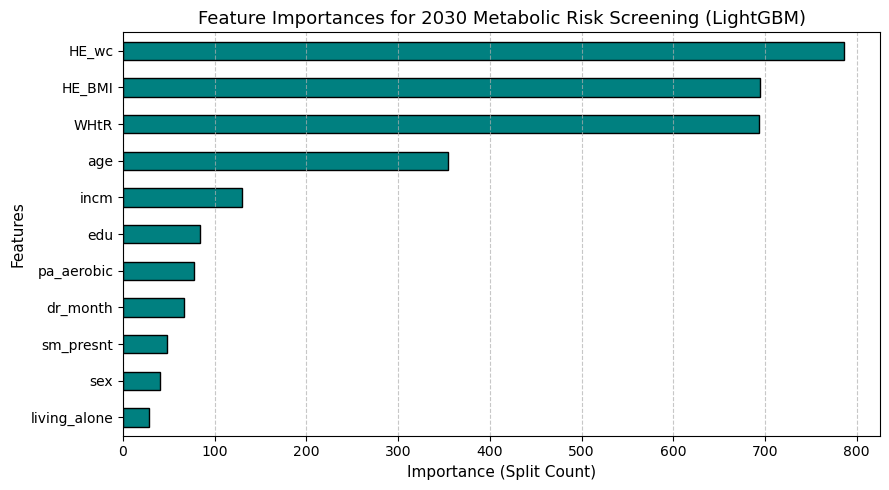

=== 변수 중요도 순위 (높은 순) ===
HE_wc           786
HE_BMI          694
WHtR            693
age             354
incm            130
edu              84
pa_aerobic       77
dr_month         66
sm_presnt        48
sex              40
living_alone     28


In [9]:
#LightGBM 모델은 트리 기반임으로 판별할때 어떤 수치를 유심히 봤나 보기 위하여 사용
best_model = models['LightGBM']
importances = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=True)
plt.figure(figsize=(9, 5))
importances.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Feature Importances for 2030 Metabolic Risk Screening (LightGBM)', fontsize=13)
plt.xlabel('Importance (Split Count)', fontsize=11)
plt.ylabel('Features', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print("=== 변수 중요도 순위 (높은 순) ===")
print(importances.sort_values(ascending=False).to_string())

**결과**: 허리둘레 786 > BMI 694 > WHtR 693 > 나이 354 > 소득 130 > 교육 84 > 운동 77 > 음주 66 > 흡연 48 > 성별 40 > 1인 가구 28.
체형 변수 세 개가 가장 많이 쓰였습니다.

> **주의: 중요도 읽을 때**
> 1. 변수 이름은 `best_model`이지만, 실제로 가장 성능이 좋은 모델은 로지스틱 회귀입니다. 이 그래프는 **LightGBM**의 중요도입니다.
> 2. split 횟수는 **연속값에 유리**합니다. 허리둘레·BMI·나이는 나눌 자리가 많지만, 0/1 변수(흡연, 성별)는 한 가지 방식으로만 나눌 수 있어 숫자가 작게 나옵니다. 그래서 "흡연은 덜 중요하다"고 읽으면 안 됩니다(11장에서 흡연 오즈비는 1.5로 뚜렷합니다).
> 3. 위험을 **올리는지 내리는지**(방향)는 알려 주지 않습니다.
> 4. 허리둘레·BMI·WHtR는 서로 거의 같은 정보라 중요도를 나눠 갖습니다.

## 9. Table 1: 위험군과 정상군 비교

논문의 첫 번째 표로, 두 집단이 어떻게 다른지 보여 줍니다.
- **연속형**(나이, 키, 허리둘레 등): 평균 ± 표준편차. 차이 검정은 **Welch t-검정**(`equal_var=False`, 두 집단의 퍼짐 정도가 달라도 되는 t-검정)입니다.
- **범주형**(성별, 흡연 등): 값이 1인 사람의 비율(%). 차이 검정은 **카이제곱 검정**입니다.
- p < 0.05면 "우연으로 보기 어려운 차이"로 봅니다.

In [10]:
from scipy import stats

# 비교할 주요 변수들 정의 (연속형 변수와 범주형 변수)
cont_vars = ['age', 'HE_ht', 'HE_wt', 'HE_BMI', 'HE_wc', 'WHtR', 'HE_glu', 'HE_sbp', 'HE_dbp', 'HE_TG', 'HE_HDL_st2']
cat_vars = ['sex', 'incm', 'sm_presnt', 'dr_month', 'pa_aerobic','living_alone']

table1_rows = []

# 연속형 변수 t-test 및 Mean ± SD 계산
for var in cont_vars:
    g0 = data_clean[data_clean['Target'] == 0][var].dropna()
    g1 = data_clean[data_clean['Target'] == 1][var].dropna()
    
    # 두 집단 독립표본 t-검정
    stat, pval = stats.ttest_ind(g0, g1, equal_var=False)
    p_str = "< 0.001" if pval < 0.001 else f"{pval:.3f}"
    
    table1_rows.append({
        'Variable': var,
        'Normal Group (Target=0)': f"{g0.mean():.1f} ± {g0.std():.1f}",
        'Risk Group (Target=1)': f"{g1.mean():.1f} ± {g1.std():.1f}",
        'p-value': p_str
    })

for var in cat_vars:
    ct = pd.crosstab(data_clean[var], data_clean['Target'])
    chi2, pval, _, _ = stats.chi2_contingency(ct)
    p_str = "< 0.001" if pval < 0.001 else f"{pval:.3f}"
    
    # 1인 비율(예: 남성 비율, 흡연율, 음주율 등)
    pct0 = (data_clean[data_clean['Target'] == 0][var] == 1).mean() * 100
    pct1 = (data_clean[data_clean['Target'] == 1][var] == 1).mean() * 100
    
    table1_rows.append({
        'Variable': f"{var} (Yes %)",
        'Normal Group (Target=0)': f"{pct0:.1f}%",
        'Risk Group (Target=1)': f"{pct1:.1f}%",
        'p-value': p_str
    })

table1_df = pd.DataFrame(table1_rows)
print("=== Table 1: Baseline Characteristics of Study Population ===")
table1_df

=== Table 1: Baseline Characteristics of Study Population ===


,Variable,Normal Group (Target=0),Risk Group (Target=1),p-value
0,age,28.6 ± 5.9,30.7 ± 5.8,< 0.001
1,HE_ht,167.0 ± 8.3,169.8 ± 8.7,< 0.001
2,HE_wt,62.3 ± 12.8,76.0 ± 16.4,< 0.001
3,HE_BMI,22.2 ± 3.5,26.2 ± 4.7,< 0.001
4,HE_wc,75.6 ± 9.8,87.9 ± 12.2,< 0.001
5,WHtR,0.5 ± 0.1,0.5 ± 0.1,< 0.001
6,HE_glu,88.5 ± 5.8,97.8 ± 20.8,< 0.001
7,HE_sbp,108.1 ± 9.3,117.8 ± 13.0,< 0.001
8,HE_dbp,68.0 ± 6.6,75.3 ± 10.1,< 0.001
9,HE_TG,76.8 ± 27.4,166.3 ± 118.5,< 0.001


**결과 읽기**: 위험군은 정상군보다 나이가 많고(30.7 vs 28.6세), 허리둘레가 크고(87.9 vs 75.6cm), BMI가 높고(26.2 vs 22.2), 남성 비율(59.4% vs 37.3%)과 흡연율(23.4% vs 12.6%)이 높습니다. 월간 음주는 차이가 없고(p = 0.497), 유산소 운동은 조금 낮으며(p = 0.036), 1인 가구 비율 차이는 유의하지 않습니다(p = 0.069).

> **주의: 표 읽을 때**
> - 혈당·혈압·중성지방·HDL은 **정답을 만든 기준 그 자체**라 차이가 나는 게 당연합니다. p < 0.001이 새로운 발견은 아닙니다.
> - WHtR가 두 집단 모두 "0.5 ± 0.1"로 보이는 것은 소수 첫째 자리 반올림 때문입니다. **정리자 확인**: 0.453 ± 0.053 vs 0.517 ± 0.066.
> - "sex (Yes %)"는 sex = 1, 즉 **남성 비율**입니다. "incm (Yes %)"는 incm = 1, 즉 **소득 하위 25% 비율**입니다(p값은 4단계 전체 비교).
> - 교육(`edu`)은 입력으로 썼지만 표에 없습니다.
> - 중성지방처럼 한쪽으로 치우친 값(위험군 평균 166, 표준편차 119)은 중앙값(사분위범위)이 더 적절합니다. **정리자 확인**: 72(56–94) vs 148.5(96–195).
> - 조사 가중치를 쓰지 않은 표본 수치라, 한국 청년 전체를 대표하는 값은 아닙니다.

## 10. 실제 선별 기준 정하기: Youden 지수와 혼동행렬

모델은 확률을 내놓으므로, 실제로 쓰려면 **"몇 % 이상이면 '위험'으로 판정할지"** 기준이 필요합니다.
- 기준을 낮추면 위험군을 많이 찾지만(민감도↑) 정상인도 많이 걸립니다(특이도↓). 기준을 높이면 그 반대입니다.
- **Youden 지수** J = 민감도 + 특이도 − 1. 기준을 바꿔 가며 J가 가장 큰 곳을 고릅니다. **민감도와 특이도를 똑같이 중요하게 볼 때**의 최적점입니다.
- **혼동행렬**: 실제(정상/위험) × 판정(정상/위험)의 4칸 표입니다.

수학적 최적의 위험 판정 기준치(Threshold): 0.363
모델의 민감도(Sensitivity, 질환 포착률) : 75.5%
모델의 특이도(Specificity, 정상 감별률) : 74.4%



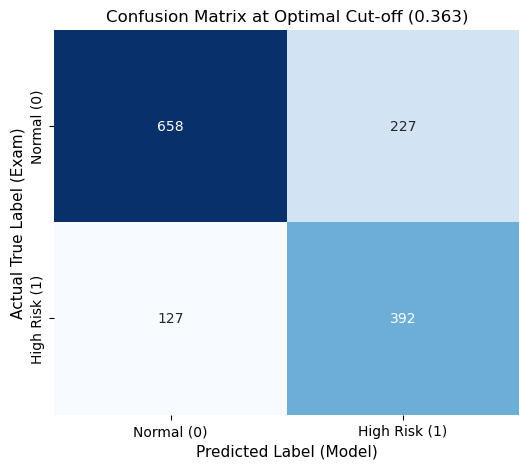

=== 상세 분류 성능 보고서 ===
              precision    recall  f1-score   support

      Normal       0.84      0.74      0.79       885
   High Risk       0.63      0.76      0.69       519

    accuracy                           0.75      1404
   macro avg       0.74      0.75      0.74      1404
weighted avg       0.76      0.75      0.75      1404



In [11]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 로지스틱 회귀의 시험 데이터 예측 확률 가져오기
lr_model = models['Logistic Regression']
y_proba = lr_model.predict_proba(X_test)[:, 1]

# 유덴지수로 수학적 최적의 임계치 계산
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
youden_j = tpr - fpr
opt_idx = np.argmax(youden_j)
opt_threshold = thresholds[opt_idx]

# 최적 기준치를 적용한 예측값 결정 (0 또는 1)
y_pred_opt = (y_proba >= opt_threshold).astype(int)

# 혼동행렬(Confusion Matrix) 계산
cm = confusion_matrix(y_test, y_pred_opt)
tn, fp, fn, tp = cm.ravel()
# ravel함수는 1차원 평면으로 펼쳐서 변수에 넣음

sensitivity = tp / (tp + fn)  # 민감도 (진짜 위험군을 맞힌 비율)
specificity = tn / (tn + fp)  # 특이도 (정상인을 정상으로 맞힌 비율)

print(f"수학적 최적의 위험 판정 기준치(Threshold): {opt_threshold:.3f}")
print(f"모델의 민감도(Sensitivity, 질환 포착률) : {sensitivity * 100:.1f}%")
print(f"모델의 특이도(Specificity, 정상 감별률) : {specificity * 100:.1f}%\n")


plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False,
            xticklabels=['Normal (0)', 'High Risk (1)'],
            yticklabels=['Normal (0)', 'High Risk (1)'])
plt.title(f'Confusion Matrix at Optimal Cut-off ({opt_threshold:.3f})', fontsize=12)
plt.xlabel('Predicted Label (Model)', fontsize=11)
plt.ylabel('Actual True Label (Exam)', fontsize=11)
plt.show()

print("=== 상세 분류 성능 보고서 ===")
print(classification_report(y_test, y_pred_opt, target_names=['Normal', 'High Risk']))

**결과** (기준 0.363, 시험 데이터 1,404명, 숫자는 위 그림에서 옮김)

| | 모델: 정상 | 모델: 위험 | 합계 |
|---|---|---|---|
| **실제 정상** | 658 (맞게 정상) | 227 (헛경보) | 885 |
| **실제 위험** | 127 (놓침) | 392 (찾아냄) | 519 |

| 지표 | 계산 | 값 | 쉬운 뜻 |
|---|---|---|---|
| 민감도 | 392 / 519 | **75.5%** | 실제 위험군 4명 중 3명을 찾음 |
| 특이도 | 658 / 885 | **74.4%** | 실제 정상인 4명 중 3명을 정상으로 봄 |
| 정밀도(양성 예측도) | 392 / 619 | 63.3% | '위험' 판정 10명 중 약 6명이 진짜 위험군 |
| 음성 예측도 | 658 / 785 | 83.8% | '정상' 판정자 중 진짜 정상 비율 |
| 위험 판정 비율 | 619 / 1,404 | 44.1% | 10명 중 4명 이상에게 검사를 권하게 됨 |

> **주의**
> 1. 기준 0.363을 **시험 데이터로 골라서 같은 시험 데이터에 적용**했습니다. 그래서 민감도·특이도가 실제보다 조금 좋게 나올 수 있습니다. 정석은 학습 데이터(교차검증)에서 기준을 정하고 시험 데이터에는 한 번만 적용하는 것입니다.
> 2. 원본 주석 "수학적 최적"은 "민감도와 특이도를 같은 무게로 볼 때의 최적"이라는 뜻입니다. 선별검사에서는 놓치는 사람을 줄이려고 민감도를 더 높게 잡는 경우가 많습니다.

## 11. Table 2: 어떤 요인이 위험과 관련 있나 (다변량 조정 오즈비)

- 로지스틱 회귀를 **WHtR를 뺀 10개 변수**로 다시 학습합니다. WHtR는 허리둘레와 키로 만든 값이라 허리둘레와 정보가 겹치기 때문입니다.
- **aOR(조정 오즈비)** = $e^{\beta}$: **나머지 변수가 모두 같을 때** 그 변수가 1 늘면 위험군일 오즈가 몇 배가 되는지. 1보다 크면 위험 요인, 작으면 보호 쪽 요인입니다.
- **95% 신뢰구간**: 참값이 있을 법한 범위입니다. 구간에 1이 들어 있지 않으면 통계적으로 유의(p < 0.05)합니다.
- 코드는 표준오차를 직접 계산합니다(각 사람의 p(1 − p)로 가중한 정보 행렬의 역행렬).

In [12]:
analysis_features = [f for f in features if f != 'WHtR']

# 통계적 인과 분석을 위한 로지스틱 회귀 모델 학습
X_train_stat = X_train[analysis_features]
lr_stat = LogisticRegression(max_iter=1000, random_state=42)
lr_stat.fit(X_train_stat, y_train)


# 로지스틱 회귀 계수(Beta)와 오즈비(Odds Ratio = exp(Beta)) 계산
coef = lr_stat.coef_[0]
odds_ratios = np.exp(coef)

# 2. 통계적 95% 신뢰구간 근사 계산 (Standard Error 추정)
# 디자인 행렬 X에 절편(상수항) 추가
X_mat = np.hstack([np.ones((X_train_stat.shape[0], 1)), X_train_stat.values])
p_train = lr_stat.predict_proba(X_train_stat)[:, 1]
V = p_train * (1 - p_train)
cov = np.linalg.inv(np.dot(X_mat.T, X_mat * V[:, np.newaxis]))
se = np.sqrt(np.diag(cov))[1:]  # 각 독립변수별 표준오차

# 95% 신뢰구간 (CI) 및 z-score, p-value 계산
ci_lower = np.exp(coef - 1.96 * se)
ci_upper = np.exp(coef + 1.96 * se)
z_scores = coef / se
p_values = 2 * (1 - stats.norm.cdf(np.abs(z_scores)))


or_df = pd.DataFrame({
    'Variable': analysis_features,
    'Beta (계수)': coef.round(3),
    'Odds Ratio (aOR)': odds_ratios.round(3),
    '95% CI (하한 ~ 상한)': [f"{l:.3f} ~ {u:.3f}" for l, u in zip(ci_lower, ci_upper)],
    'p-value': ["< 0.001" if p < 0.001 else f"{p:.3f}" for p in p_values]
}).sort_values(by='Odds Ratio (aOR)', ascending=False)

print("=== Table 2: Multivariate Adjusted Odds Ratios (aOR) ===")
print(or_df.to_string(index=False))

=== Table 2: Multivariate Adjusted Odds Ratios (aOR) ===
    Variable  Beta (계수)  Odds Ratio (aOR) 95% CI (하한 ~ 상한) p-value
   sm_presnt      0.407             1.502    1.200 ~ 1.881 < 0.001
         sex      0.102             1.108    0.889 ~ 1.380   0.361
       HE_wc      0.102             1.107    1.083 ~ 1.132 < 0.001
         age      0.045             1.046    1.029 ~ 1.062 < 0.001
      HE_BMI     -0.001             0.999    0.947 ~ 1.055   0.979
        incm     -0.075             0.928    0.858 ~ 1.003   0.061
  pa_aerobic     -0.124             0.883    0.742 ~ 1.050   0.160
    dr_month     -0.152             0.859    0.720 ~ 1.025   0.091
         edu     -0.180             0.835    0.703 ~ 0.992   0.040
living_alone     -0.276             0.759    0.598 ~ 0.962   0.023


**결과 쉽게 읽기**

| 변수 | aOR (95% CI) | 쉬운 해석 |
|---|---|---|
| 현재 흡연 | 1.502 (1.200–1.881) | 흡연자는 비흡연자보다 위험군일 오즈가 약 1.5배 |
| 허리둘레 | 1.107 (1.083–1.132) / cm | 1cm당 약 10.7%↑, 10cm면 약 2.8배 |
| 나이 | 1.046 (1.029–1.062) / 세 | 1살당 4.6%↑, 10살이면 약 1.6배 |
| 교육수준 | 0.835 (0.703–0.992) / 단계 | 한 단계 높을수록 오즈 약 16.5%↓ (p = 0.040) |
| 1인 가구 | 0.759 (0.598–0.962) | 다른 조건이 같으면 1인 가구가 오히려 오즈 약 24%↓ (p = 0.023) |
| 성별, BMI, 소득, 운동, 음주 | 구간이 1을 포함 | 다른 변수를 고려하면 뚜렷한 관련이 확인되지 않음 |

> **주의**
> - 원본 주석 "통계적 인과 분석" → 한 시점에 조사한 자료(단면 연구)라 **원인**이 아니라 **관련성**입니다. "흡연이 원인"이 아니라 "흡연과 관련"으로 써야 합니다.
> - BMI aOR 0.999는 "BMI가 무관하다"는 뜻이 아닙니다. 허리둘레와 BMI가 거의 같은 정보를 담고 있어서, 허리둘레를 넣으면 BMI가 추가로 설명할 몫이 거의 남지 않는 것입니다(다중공선성).
> - 성별: Table 1에서는 남성 비율 차이가 컸지만 여기서는 유의하지 않습니다. 성별 차이의 대부분이 허리둘레 같은 체형 차이로 설명된다는 뜻입니다.
> - 소득·교육을 1–4 숫자로 넣었으므로 "한 단계 오를 때마다 같은 만큼 효과"라고 가정한 것입니다.
> - scikit-learn `LogisticRegression`은 기본으로 L2 규제가 있어 계수가 약간 줄어든 상태이고, 표준오차 공식은 규제 없는 모델 기준입니다. 논문용이면 `statsmodels`의 Logit(규제 없음)으로 계산하는 것이 정석입니다. 또 이 표는 학습 데이터 70%(3,276명)로만 계산했습니다.

## 12. Forest plot: 오즈비 한눈에 보기

- **점** = aOR, **가로선** = 95% 신뢰구간, **회색 점선** = 1(관련 없음)
- 점선 오른쪽은 위험 쪽, 왼쪽은 보호 쪽입니다. 가로선이 점선에 닿지 않으면 유의합니다.

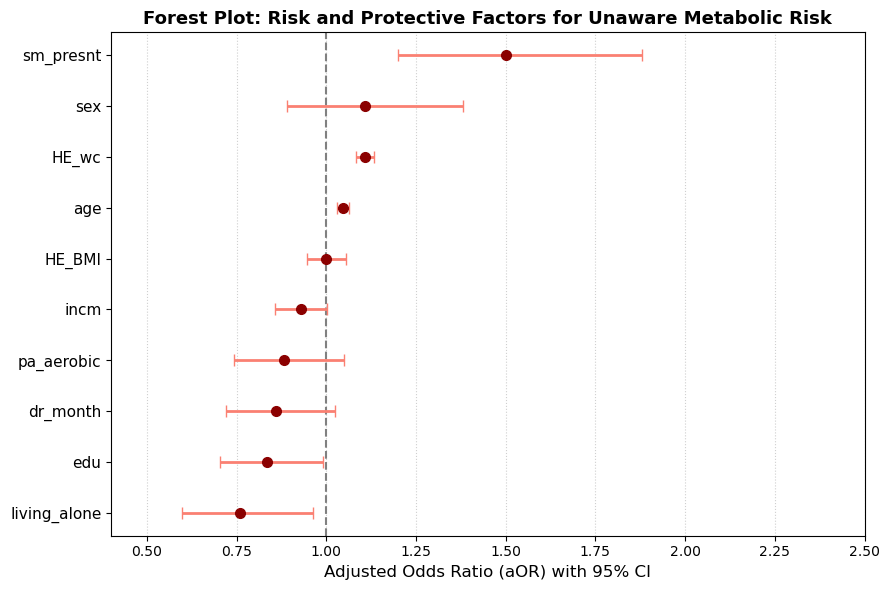

In [13]:
# 정렬된 오즈비 데이터 준비 (상수항 제외)
plot_df = or_df.sort_values(by='Odds Ratio (aOR)', ascending=True).copy()

plt.figure(figsize=(9, 6))

# 기준선 1.0 그리기 (1.0보다 크면 위험 요인, 작으면 보호 요인)
plt.axvline(x=1.0, color='gray', linestyle='--', linewidth=1.5, label='Baseline (OR = 1.0)')


y_pos = range(len(plot_df))
ci_lowers = [float(ci.split(' ~ ')[0]) for ci in plot_df['95% CI (하한 ~ 상한)']]
ci_uppers = [float(ci.split(' ~ ')[1]) for ci in plot_df['95% CI (하한 ~ 상한)']]
errors = [
    plot_df['Odds Ratio (aOR)'] - ci_lowers,
    ci_uppers - plot_df['Odds Ratio (aOR)']
]

plt.errorbar(plot_df['Odds Ratio (aOR)'], y_pos, xerr=errors, fmt='o', 
             color='darkred', ecolor='salmon', elinewidth=2, capsize=4, markersize=7)

plt.yticks(y_pos, plot_df['Variable'], fontsize=11)
plt.xlim(0.4, 2.5)  # 직관적 비교를 위한 범위 설정
plt.xlabel('Adjusted Odds Ratio (aOR) with 95% CI', fontsize=12)
plt.title('Forest Plot: Risk and Protective Factors for Unaware Metabolic Risk', fontsize=13, fontweight='bold')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

**읽기**: 흡연·허리둘레·나이는 점선 오른쪽에 떨어져 있고, 1인 가구·교육은 왼쪽에 떨어져 있습니다. 나머지는 점선을 가로지릅니다. 허리둘레의 구간이 아주 짧은 것은 1cm 단위라 효과 자체는 작지만 매우 정밀하게 추정됐기 때문입니다. 가로축은 0.4–2.5로 고정돼 있습니다.

## 13. 성별 · 연령대 하위집단 분석

세 가지를 합니다.
1. 성별 × 연령대(20대/30대) 위험군 비율 그래프
2. 20대와 30대를 따로 떼어 각각 로지스틱 회귀를 학습하고 ROC-AUC 비교
3. 성별 × 연령대 4개 그룹에서 흡연의 오즈비 비교

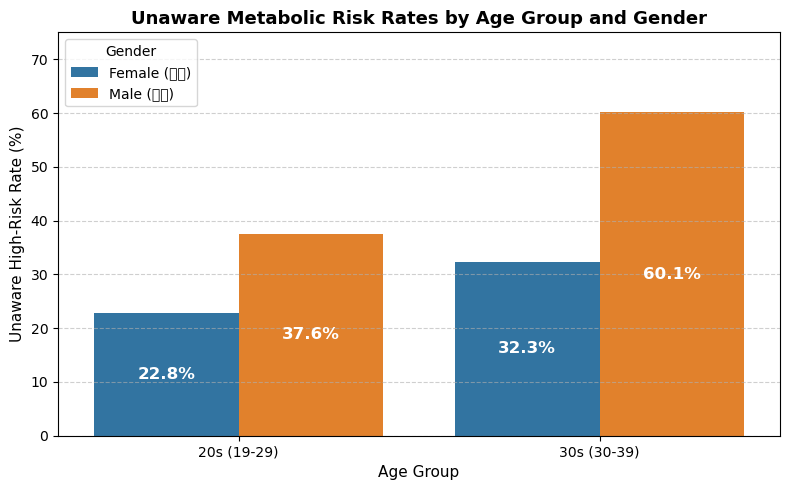

20대 전체 모델 판별력(ROC-AUC): 0.779
30대 전체 모델 판별력(ROC-AUC): 0.808

=== [세부 분석] 성별 및 연령대별 4개 세부 그룹의 흡연 위험도(aOR) 비교 ===
         성별         연령대  표본수(N)  흡연 Beta(계수)  조정 오즈비(aOR)
  Male (남성) 20s (19-29)    1118        0.194        1.215
  Male (남성) 30s (30-39)    1010        0.552        1.737
Female (여성) 20s (19-29)    1278        0.557        1.745
Female (여성) 30s (30-39)    1274        0.341        1.406


In [14]:
# 1. 20대(19~29세)와 30대(30~39세) 그룹 분할 및 성별 라벨링
data_clean['age_group'] = np.where(data_clean['age'] < 30, '20s (19-29)', '30s (30-39)')
data_clean['gender'] = np.where(data_clean['sex'] == 1, 'Male (남성)', 'Female (여성)')

# 2. 성별 x 연령대별 미인지 대사이상 위험군 비율(%) 계산 및 막대그래프 시각화
sub_stats = data_clean.groupby(['gender', 'age_group'])['Target'].agg(['count', 'mean']).reset_index()
sub_stats['Risk_Pct'] = sub_stats['mean'] * 100

plt.figure(figsize=(8, 5))
bar_plot = sns.barplot(data=sub_stats, x='age_group', y='Risk_Pct', hue='gender', palette=['#1f77b4', '#ff7f0e'])

for p in bar_plot.patches:
    height = p.get_height()
    if height > 0:
        bar_plot.annotate(f'{height:.1f}%', 
                          (p.get_x() + p.get_width() / 2., height / 2),
                          ha='center', va='center', fontsize=12, color='white', fontweight='bold')

plt.title('Unaware Metabolic Risk Rates by Age Group and Gender', fontsize=13, fontweight='bold')
plt.xlabel('Age Group', fontsize=11)
plt.ylabel('Unaware High-Risk Rate (%)', fontsize=11)
plt.ylim(0, 75)
plt.legend(title='Gender', loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 3. 20대 코호트 vs 30대 코호트 독립 학습 및 판별력(ROC-AUC) 비교
d20 = data_clean[data_clean['age'] < 30]
d30 = data_clean[data_clean['age'] >= 30]
sub_feats = ['incm', 'edu', 'HE_BMI', 'HE_wc', 'sm_presnt', 'dr_month', 'pa_aerobic', 'living_alone']

m20 = LogisticRegression(max_iter=1000, random_state=42).fit(d20[sub_feats + ['sex']], d20['Target'])
m30 = LogisticRegression(max_iter=1000, random_state=42).fit(d30[sub_feats + ['sex']], d30['Target'])

auc20 = roc_auc_score(d20['Target'], m20.predict_proba(d20[sub_feats + ['sex']])[:, 1])
auc30 = roc_auc_score(d30['Target'], m30.predict_proba(d30[sub_feats + ['sex']])[:, 1])

print(f"20대 전체 모델 판별력(ROC-AUC): {auc20:.3f}")
print(f"30대 전체 모델 판별력(ROC-AUC): {auc30:.3f}\n")

# 4.성별 x 연령대별 4개 세부 그룹의 흡연 위험 가중치(Beta 및 aOR) 비교
group_results = []
for g_name, g_val in [('Male (남성)', 1), ('Female (여성)', 2)]:
    for a_name, a_cond in [('20s (19-29)', data_clean['age'] < 30), ('30s (30-39)', data_clean['age'] >= 30)]:
        sub = data_clean[(data_clean['sex'] == g_val) & a_cond]
        m_sub = LogisticRegression(max_iter=1000, random_state=42).fit(sub[sub_feats], sub['Target'])
        sm_idx = sub_feats.index('sm_presnt')
        beta = m_sub.coef_[0][sm_idx]
        aor = np.exp(beta)
        group_results.append({
            '성별': g_name,
            '연령대': a_name,
            '표본수(N)': len(sub),
            '흡연 Beta(계수)': round(beta, 3),
            '조정 오즈비(aOR)': round(aor, 3)
        })

smoke_df = pd.DataFrame(group_results)
print("=== [세부 분석] 성별 및 연령대별 4개 세부 그룹의 흡연 위험도(aOR) 비교 ===")
print(smoke_df.to_string(index=False))

**결과**

| 그룹 | 위험군 비율 |
|---|---|
| 20대 여성 | 22.8% |
| 20대 남성 | 37.6% |
| 30대 여성 | 32.3% |
| 30대 남성 | **60.1%** (10명 중 6명) |

- 20대 모델 ROC-AUC 0.779, 30대 모델 0.808
- 흡연 aOR: 남성 20대 1.215, 남성 30대 1.737, 여성 20대 1.745, 여성 30대 1.406

> **주의**
> - 20대/30대 AUC는 **학습에 쓴 데이터로 다시 평가**한 값입니다(시험 데이터를 따로 두지 않음). 실제보다 좋게 나오므로, 앞의 0.805(시험 데이터)와 직접 비교할 수 없습니다. 또 이 모델들에는 나이가 들어 있지 않습니다.
> - 그룹별 흡연 aOR에는 신뢰구간과 p값이 없고, 그룹당 1,000명 남짓입니다. 그룹 간 차이(예: 1.2 vs 1.7)가 우연인지 판단할 수 없습니다.
> - 그래프 범례의 한글이 네모(□)로 깨집니다. 코드 맨 앞에 `plt.rcParams['font.family'] = 'Malgun Gothic'`과 `plt.rcParams['axes.unicode_minus'] = False`를 넣으면 해결됩니다(Windows 기준).

## 14. 1인 가구(자취) 청년 분석

1인 가구(`cfam == 1`)와 가족과 사는 청년을 비교합니다.
- **A**: 성별 × 가구 형태별 현재 흡연율
- **B**: 30대의 고혈압 위험·고중성지방·복부비만 비율
- 20대·30대 성별 × 가구 형태별 세부 표

복부비만은 허리둘레 남자 90cm, 여자 85cm 이상(한국 기준)입니다. 정답(Target)에는 들어가지 않은 별도 지표입니다.

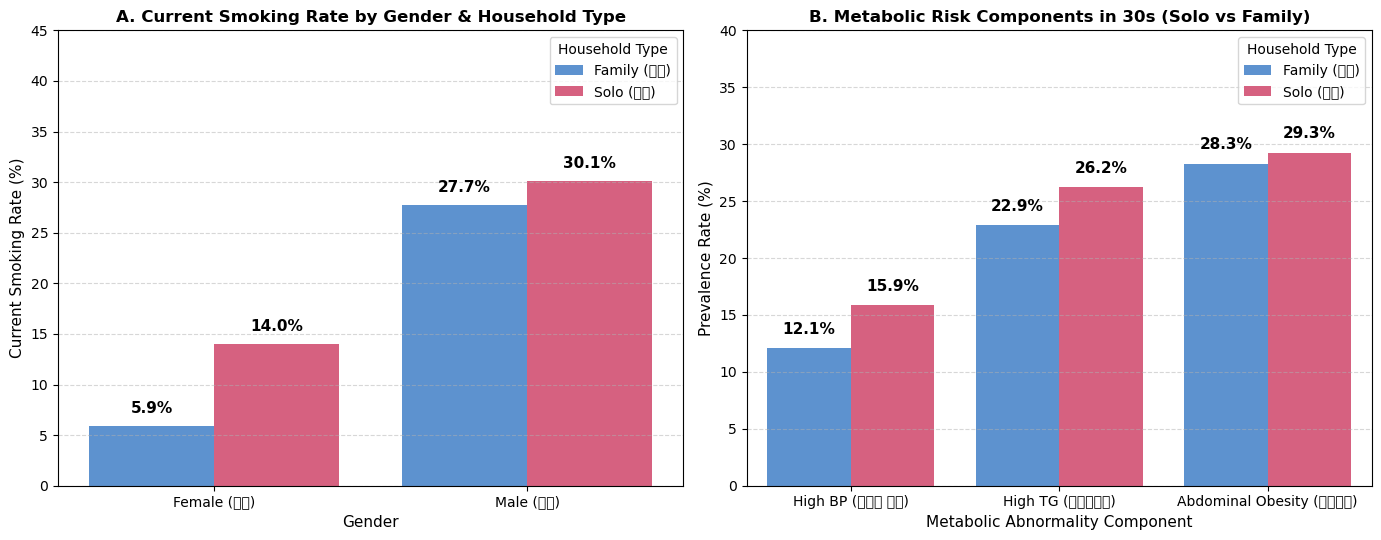

=== 청년 1인 가구(자취) 건강 행태 및 대사위험 통계 요약 ===
1. [핵심 매개 원인] 여성 자취 청년 흡연율: 14.0% vs 가족동거: 5.9% (카이제곱 p-value: 1.70e-07)
2. [대사이상 전체] 30대 자취 청년 고혈압 위험: 15.9% vs 가족동거: 12.1%
3. [대사이상 전체] 30대 자취 청년 고중성지방 위험: 26.2% vs 가족동거: 22.9%

=== [세부 분석 1] 20대 성별 x 가구형태별 대사위험 지표 ===
                         표본수(N)  고혈압 위험(%)  고중성지방(%)  복부비만(%)
gender      household                                        
Female (여성) Family (동거)    1080        1.8       7.6     10.2
            Solo (자취)       198        2.0       7.1      9.1
Male (남성)   Family (동거)     890       14.0      21.3     28.8
            Solo (자취)       228        9.6      15.4     27.2

=== [세부 분석 2] 30대 성별 x 가구형태별 대사위험 지표 ===
                         표본수(N)  고혈압 위험(%)  고중성지방(%)  복부비만(%)
gender      household                                        
Female (여성) Family (동거)    1143        5.8      11.7     19.2
            Solo (자취)       131        5.3      11.5     18.3
Male (남성)   Family (동거)     813       20.9      38.6     41.1
            Sol

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats

# 1. 가구 형태 및 라벨링
data_clean['household'] = np.where(data_clean['living_alone'] == 1, 'Solo (자취)', 'Family (동거)')
data_clean['gender'] = np.where(data_clean['sex'] == 1, 'Male (남성)', 'Female (여성)')
data_clean['age_group'] = np.where(data_clean['age'] < 30, '20s (19-29)', '30s (30-39)')

# 2. 대사위험 세부 지표 정의 (혈압, 중성지방, 복부비만)
data_clean['high_bp'] = np.where((data_clean['HE_sbp'] >= 130) | (data_clean['HE_dbp'] >= 85), 1, 0)
data_clean['high_tg'] = np.where(data_clean['HE_TG'] >= 150, 1, 0)
data_clean['ab_obesity'] = np.where(
    ((data_clean['sex'] == 1) & (data_clean['HE_wc'] >= 90)) | 
    ((data_clean['sex'] == 2) & (data_clean['HE_wc'] >= 85)), 1, 0
)

# 3. 2분할 시각화 차트 (Figure 4: Panel A - 성별 흡연율 격차 / Panel B - 30대 대사이상 지표 격차)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# [Panel A] 성별 x 가구형태별 현재 흡연율 비교 (1등 생활습관 위험 인자의 격차)
sm_stats = data_clean.groupby(['gender', 'household'])['sm_presnt'].agg(['count', 'mean']).reset_index()
sm_stats['Smoking_Pct'] = sm_stats['mean'] * 100

bar_a = sns.barplot(data=sm_stats, x='gender', y='Smoking_Pct', hue='household', 
                    palette=['#4a90e2', '#e94e77'], ax=axes[0])
axes[0].set_title('A. Current Smoking Rate by Gender & Household Type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=11)
axes[0].set_ylabel('Current Smoking Rate (%)', fontsize=11)
axes[0].set_ylim(0, 45)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].legend(title='Household Type', loc='upper right')

for p in bar_a.patches:
    h = p.get_height()
    if h > 0:
        bar_a.annotate(f'{h:.1f}%', (p.get_x() + p.get_width() / 2., h + 1),
                       ha='center', va='bottom', fontsize=11, fontweight='bold')

# [Panel B] 30대 청년의 가구형태별 주요 대사이상 3대 지표 유병률 비교 (대사질환 결과)
d30 = data_clean[data_clean['age_group'] == '30s (30-39)']
mets_comp = pd.DataFrame({
    'Condition': [
        'High BP (고혈압 위험)', 'High BP (고혈압 위험)',
        'High TG (고중성지방)', 'High TG (고중성지방)',
        'Abdominal Obesity (복부비만)', 'Abdominal Obesity (복부비만)'
    ],
    'Household': [
        'Family (동거)', 'Solo (자취)',
        'Family (동거)', 'Solo (자취)',
        'Family (동거)', 'Solo (자취)'
    ],
    'Rate (%)': [
        d30[d30['living_alone'] == 0]['high_bp'].mean() * 100,
        d30[d30['living_alone'] == 1]['high_bp'].mean() * 100,
        d30[d30['living_alone'] == 0]['high_tg'].mean() * 100,
        d30[d30['living_alone'] == 1]['high_tg'].mean() * 100,
        d30[d30['living_alone'] == 0]['ab_obesity'].mean() * 100,
        d30[d30['living_alone'] == 1]['ab_obesity'].mean() * 100
    ]
})

bar_b = sns.barplot(data=mets_comp, x='Condition', y='Rate (%)', hue='Household',
                    palette=['#4a90e2', '#e94e77'], ax=axes[1])
axes[1].set_title('B. Metabolic Risk Components in 30s (Solo vs Family)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Metabolic Abnormality Component', fontsize=11)
axes[1].set_ylabel('Prevalence Rate (%)', fontsize=11)
axes[1].set_ylim(0, 40)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].legend(title='Household Type', loc='upper right')

for p in bar_b.patches:
    h = p.get_height()
    if h > 0:
        bar_b.annotate(f'{h:.1f}%', (p.get_x() + p.get_width() / 2., h + 1),
                       ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# 4. 통계적 유의성 검정 및 요약 출력
f_df = data_clean[data_clean['sex'] == 2]
ct_f_sm = pd.crosstab(f_df['living_alone'], f_df['sm_presnt'])
_, p_f_sm, _, _ = stats.chi2_contingency(ct_f_sm)

print("=== 청년 1인 가구(자취) 건강 행태 및 대사위험 통계 요약 ===")
print(f"1. [핵심 매개 원인] 여성 자취 청년 흡연율: {f_df[f_df['living_alone']==1]['sm_presnt'].mean()*100:.1f}% vs 가족동거: {f_df[f_df['living_alone']==0]['sm_presnt'].mean()*100:.1f}% (카이제곱 p-value: {p_f_sm:.2e})")
print(f"2. [대사이상 전체] 30대 자취 청년 고혈압 위험: {d30[d30['living_alone']==1]['high_bp'].mean()*100:.1f}% vs 가족동거: {d30[d30['living_alone']==0]['high_bp'].mean()*100:.1f}%")
print(f"3. [대사이상 전체] 30대 자취 청년 고중성지방 위험: {d30[d30['living_alone']==1]['high_tg'].mean()*100:.1f}% vs 가족동거: {d30[d30['living_alone']==0]['high_tg'].mean()*100:.1f}%\n")

# 5. [세부 분석] 20대 및 30대 성별 x 가구형태별 대사위험 3대 지표 비교
d20 = data_clean[data_clean['age_group'] == '20s (19-29)']
d30 = data_clean[data_clean['age_group'] == '30s (30-39)']

# 20대 세부 요약표
sub_20_stats = d20.groupby(['gender', 'household'])[['high_bp', 'high_tg', 'ab_obesity']].mean() * 100
sub_20_counts = d20.groupby(['gender', 'household'])['ID'].count()
summary_20 = pd.concat([sub_20_counts.rename('표본수(N)'), sub_20_stats.round(1).rename(columns={
    'high_bp': '고혈압 위험(%)',
    'high_tg': '고중성지방(%)',
    'ab_obesity': '복부비만(%)'
})], axis=1)

# 30대 세부 요약표
sub_30_stats = d30.groupby(['gender', 'household'])[['high_bp', 'high_tg', 'ab_obesity']].mean() * 100
sub_30_counts = d30.groupby(['gender', 'household'])['ID'].count()
summary_30 = pd.concat([sub_30_counts.rename('표본수(N)'), sub_30_stats.round(1).rename(columns={
    'high_bp': '고혈압 위험(%)',
    'high_tg': '고중성지방(%)',
    'ab_obesity': '복부비만(%)'
})], axis=1)

print("=== [세부 분석 1] 20대 성별 x 가구형태별 대사위험 지표 ===")
print(summary_20.to_string())
print("\n=== [세부 분석 2] 30대 성별 x 가구형태별 대사위험 지표 ===")
print(summary_30.to_string())

**결과**
- **A**: 여성 1인 가구 흡연율 **14.0%** vs 가족 동거 5.9% (p = 1.70 × 10⁻⁷, 뚜렷한 차이). 남성은 30.1% vs 27.7%.
- **B (30대 전체)**: 고혈압 위험 15.9% vs 12.1%, 고중성지방 26.2% vs 22.9%, 복부비만 29.3% vs 28.3% (1인 가구 vs 동거).

> **주의: 성별 구성 차이 때문에 생긴 착시 (심슨의 역설)**
> 30대 1인 가구는 **남성이 60.1%**(197/328)인데, 가족 동거는 41.6%(813/1,956)입니다. 남성은 모든 지표에서 여성보다 훨씬 높으므로, 1인 가구에 남성이 많은 것만으로도 전체 비율이 올라갑니다. 성별로 나눈 세부 표(위 출력)를 보면 이렇습니다.
>
> | 30대 (동거 → 1인 가구) | 고혈압 위험 | 고중성지방 | 복부비만 |
> |---|---|---|---|
> | 남성 | 20.9 → 22.8 | 38.6 → **36.0** | 41.1 → **36.5** |
> | 여성 | 5.8 → 5.3 | 11.7 → 11.5 | 19.2 → 18.3 |
>
> 남성의 혈압만 1인 가구가 조금 높고, 나머지는 1인 가구가 비슷하거나 오히려 낮습니다. 20대 남성은 세 지표 모두 1인 가구가 낮습니다. 11장에서 1인 가구 aOR이 0.759(1보다 작음)였던 것과 같은 방향입니다.
>
> - 따라서 "1인 가구는 대사이상 위험이 높다"는 이 자료로 뒷받침되지 않습니다. 뒷받침되는 것은 "**여성** 1인 가구 청년의 흡연율이 높다"는 점입니다.
> - 원본 출력의 "[핵심 매개 원인]"이라는 표현: 매개(1인 가구 → 흡연 → 대사이상)를 주장하려면 매개분석이 필요합니다. 여기서는 흡연율만 비교했으므로 "관련"으로 써야 합니다.
> - 30대 비교(B)에는 통계 검정이 없습니다.

## 15. 종합 정리

### 이 노트북이 보여 주는 것 (정확한 표현)
1. KNHANES 2021–2024년 19–39세 중 고혈압·당뇨병·이상지질혈증 **치료를 받지 않는** 4,680명에서, 채혈 없이 얻는 11개 정보로 **'대사이상 소견 1개 이상'** 을 예측했다.
2. 네 모델 중 **로지스틱 회귀가 가장 높았다**: ROC-AUC 0.805, PR-AUC 0.695 (기본 설정, 70/30 한 번 분할).
3. 확률 0.363을 기준으로 하면 시험 데이터에서 민감도 75.5%, 특이도 74.4%였다 (기준을 시험 데이터로 골라 다소 낙관적인 값).
4. 다른 요인을 고려해도 **현재 흡연, 허리둘레, 나이**가 위험과 관련 있었다 (인과가 아닌 연관).
5. **30대 남성**의 위험군 비율이 60.1%로 가장 높았다.
6. **여성 1인 가구** 청년의 흡연율이 가족과 사는 여성보다 높았다(14.0% vs 5.9%). 대사이상 지표의 1인 가구 차이는 대부분 성별 구성 차이로 설명된다.

### 이렇게 쓰면 틀린 표현
| 틀린 표현 | 바른 표현 |
|---|---|
| 대사증후군 예측 | 대사이상 소견(4개 중 1개 이상) 예측 |
| 미인지 청년 전체 | 치료받지 않는 청년 (진단받고 치료 안 받는 96명 포함) |
| 흡연이 원인 / 핵심 매개 원인 | 흡연과 관련 |
| 트리 모델보다 확실히 우수 | 이 설정에서 가장 높았음 |
| 자취가 대사이상 위험을 높임 | 여성 1인 가구의 흡연율이 높음 (대사이상 차이는 성별 구성 효과) |
| BMI는 무관 | 허리둘레와 정보가 겹쳐 추가 설명력이 작음 |

### 더 좋게 만들려면 (우선순위 순)
1. 검사값 5개 중 빈 값이 있는 사람은 정답을 만들기 전에 제외 (5장, 122명)
2. 공복 8시간 미만 혈당값 처리 (84명)
3. '미인지' 정의 맞추기: 진단받은 사람(`_dg == 1`)도 제외하거나 용어 변경 (4장)
4. Youden 기준은 학습 데이터(교차검증)에서 정하기 (10장)
5. 모델 비교는 교차검증·부트스트랩 신뢰구간으로 하고, 트리 모델은 설정을 조정한 뒤 비교 (7장)
6. KNHANES 이용지침서 권고대로 조사 가중치(`wt_itvex`)·층(`kstrata`)·집락(`psu`)을 반영
7. 오즈비는 `statsmodels` 로지스틱으로 계산 (11장)
8. 그래프 한글 폰트 설정 (13장)